In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

In [2]:
plt.style.use('seaborn-v0_8')

In [3]:
data = pd.read_csv('smaller.csv', dtype={'SOCP': str})
data['inc2024'] = data.PINCP * data.ADJINC / 1_000_000
data.shape, data.PWGTP.sum()

((3422888, 7), np.int64(340110990))

In [4]:
data = data.dropna(subset=['PWGTP', 'ADJINC', 'PINCP'])
data.shape, data.PWGTP.sum()

((2912790, 7), np.int64(280613270))

In [5]:
data = data[data.inc2024 > 0]
data.shape, data.PWGTP.sum()

((2556439, 7), np.int64(245168158))

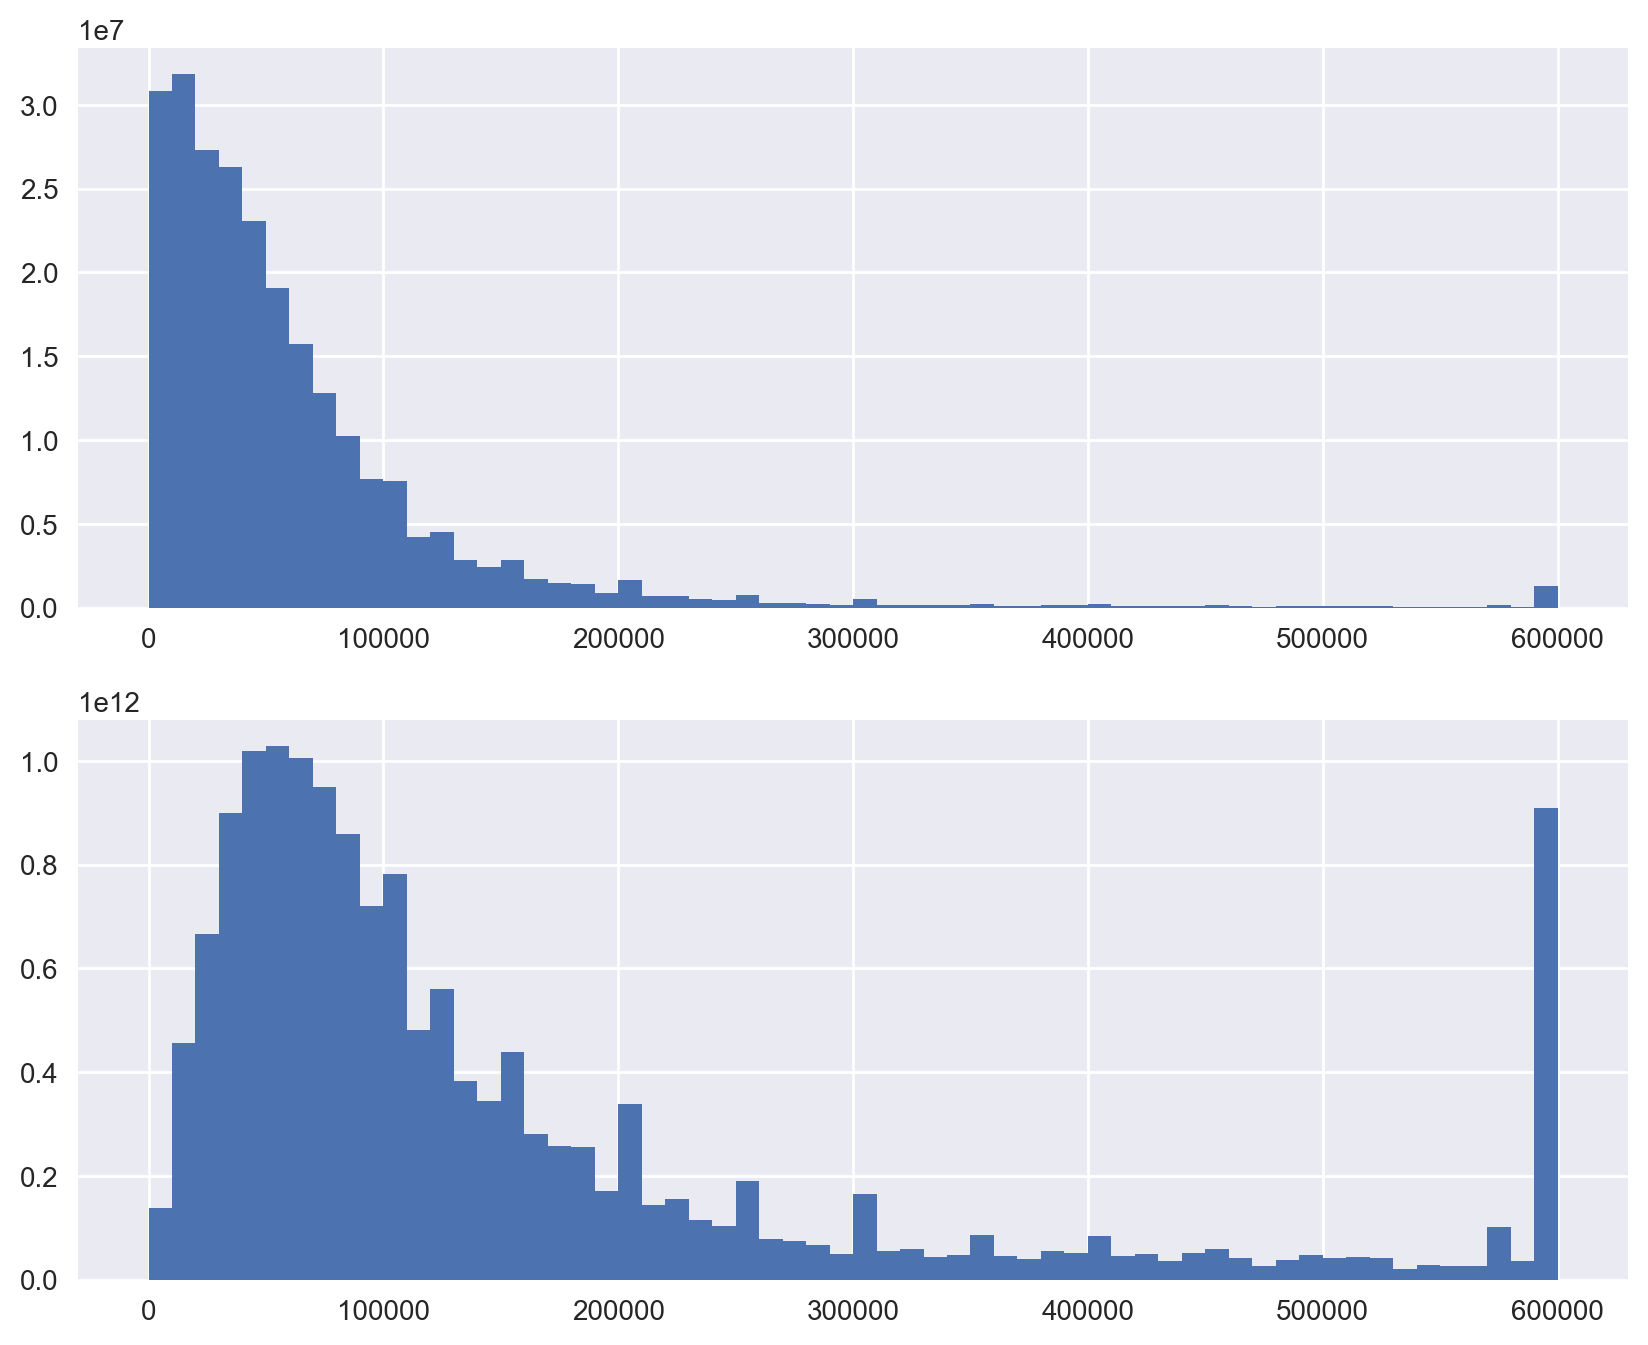

In [35]:
upper = 600_000
step = 10_000
bins = range(0, upper + step, step)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8))

ax1.hist(
    data.inc2024.clip(upper=upper),
    weights=data.PWGTP,
    bins=bins)

ax2.hist(
    data.inc2024.clip(upper=upper),
    weights=data.PWGTP * data.inc2024,
    bins=bins)

plt.show()

In [ ]:
# people per dollars?

In [40]:
print(f'{(data.inc2024 * data.PWGTP).sum():_}')

15_408_604_191_922.902


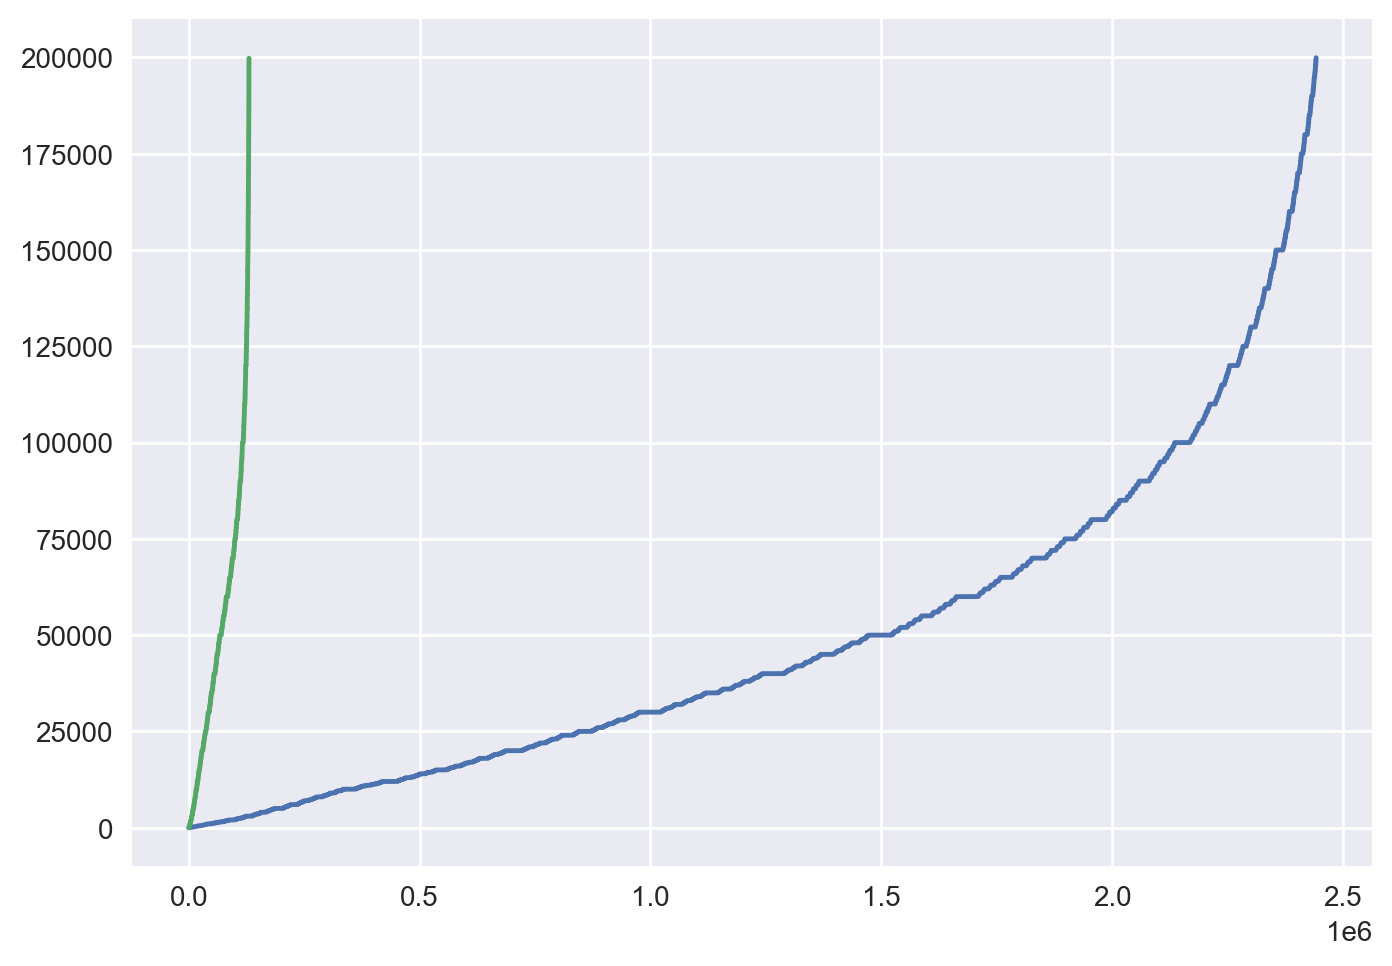

In [32]:
plt.plot(sorted(data.PINCP[data.PINCP < 200_000]))
plt.plot(sorted(data.PINCP[(data.PINCP < 200_000) & (data.SOCP.str.startswith('25'))]))